# PatchTST: Pure Transformer Forecasting for Household Energy Consumption
**Paper:** *A Time Series is Worth 64 Words: Long-term Forecasting with Transformers* (Nie et al., ICLR 2023)  
**Dataset:** Individual Household Electric Power Consumption (IHEPC) — Clamart, France (Dec 2006 – Nov 2010)

This notebook implements the **PatchTST** architecture for 24-hour-ahead multivariate energy forecasting, serving as a **third model** for comparative analysis alongside:
1. **CNN-BiLSTM** (Convolutional + Recurrent baseline)
2. **Our SOTA** (RevIN + Multi-Scale Patching + BiGRU + Cross-Variable Attention hybrid)
3. **PatchTST** (Pure Transformer with patching — this notebook)

## Key PatchTST Innovations:
1. **Subseries-Level Patching:** Segments the time series into non-overlapping patches, reducing the effective sequence length and capturing local semantic information.
2. **Channel Independence (CI):** Each variable is processed independently through a shared Transformer backbone — prevents overfitting on cross-variable noise.
3. **Vanilla Transformer Encoder:** Standard multi-head self-attention on patch tokens — no recurrent layers, no GRU, purely attention-driven.
4. **RevIN:** Reversible Instance Normalization for non-stationarity handling.
5. **Learnable Positional Encoding:** Directly learned position embeddings for patch positions.

---

## 0. Setup and Reproducibility


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import random
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

def set_seed(seed=42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)


Using device: cuda


## 1. Data Loading & Preprocessing
Identical pipeline to our existing SOTA notebook — hourly resampling, forward/backward fill, consistent column ordering.


In [6]:
def load_and_preprocess_data(filepath):
    print(f"Loading data from {filepath}...")
    df = pd.read_csv(filepath, sep=';', na_values=['?'], dtype={'Date': str, 'Time': str})
    
    initial_len = len(df)
    df = df.dropna()
    print(f"Dropped {initial_len - len(df)} missing rows.")
    
    df['Datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], format='%d/%m/%Y %H:%M:%S')
    df = df.drop(columns=['Date', 'Time']).set_index('Datetime')
    
    for col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')
        
    df_h = df.resample('h').mean()
    df_h = df_h.ffill().bfill()
    print(f"Processed Hourly Dataset Shape: {df_h.shape}")
    return df_h

# Kaggle Dataset Path
KAGGLE_PATH = '/kaggle/input/datasets/organizations/uciml/electric-power-consumption-data-set/household_power_consumption.txt'
LOCAL_PATH = '../data/household_power_consumption.txt'

if os.path.exists(KAGGLE_PATH):
    df_h = load_and_preprocess_data(KAGGLE_PATH)
elif os.path.exists(LOCAL_PATH):
    df_h = load_and_preprocess_data(LOCAL_PATH)
else:
    try:
        df_h = load_and_preprocess_data('data/household_power_consumption.txt')
    except Exception:
        print("Data file not found. Please verify the dataset path.")


Loading data from /kaggle/input/datasets/organizations/uciml/electric-power-consumption-data-set/household_power_consumption.txt...
Dropped 25979 missing rows.
Processed Hourly Dataset Shape: (34589, 7)


## 2. Cyclical Calendar Feature Engineering
Same sin/cos encoding as the SOTA notebook — hour, day-of-week, and month.


In [7]:
def get_cyclical_calendar_features(df_index):
    hours = df_index.hour.values
    days = df_index.dayofweek.values
    months = df_index.month.values
    
    hour_sin = np.sin(2 * np.pi * hours / 24.0)
    hour_cos = np.cos(2 * np.pi * hours / 24.0)
    day_sin = np.sin(2 * np.pi * days / 7.0)
    day_cos = np.cos(2 * np.pi * days / 7.0)
    month_sin = np.sin(2 * np.pi * months / 12.0)
    month_cos = np.cos(2 * np.pi * months / 12.0)
    
    calendar_feats = np.stack([hour_sin, hour_cos, day_sin, day_cos, month_sin, month_cos], axis=1)
    return calendar_feats

calendar_features = get_cyclical_calendar_features(df_h.index)
print(f"Calendar features shape: {calendar_features.shape}")


Calendar features shape: (34589, 6)


## 3. Chronological Train-Val-Test Split
Zero-leakage split:
* **Train:** Dec 2006 – Dec 2008 (~2 years)
* **Val:** Jan 2009 – Dec 2009 (1 year)
* **Test:** Jan 2010 – Nov 2010 (~11 months)


In [8]:
target_cols = ['Global_active_power', 'Global_reactive_power', 'Voltage', 'Global_intensity', 
               'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']

train_mask = df_h.index < '2009-01-01'
val_mask = (df_h.index >= '2009-01-01') & (df_h.index < '2010-01-01')
test_mask = df_h.index >= '2010-01-01'

df_train = df_h.loc[train_mask]
df_val = df_h.loc[val_mask]
df_test = df_h.loc[test_mask]

print(f"Train hours: {df_train.shape[0]}")
print(f"Val hours:   {df_val.shape[0]}")
print(f"Test hours:  {df_test.shape[0]}")

train_raw = df_train[target_cols].values
val_raw = df_val[target_cols].values
test_raw = df_test[target_cols].values

scaler = StandardScaler()
train_scaled = scaler.fit_transform(train_raw)
val_scaled = scaler.transform(val_raw)
test_scaled = scaler.transform(test_raw)

train_cal = calendar_features[train_mask]
val_cal = calendar_features[val_mask]
test_cal = calendar_features[test_mask]


Train hours: 17911
Val hours:   8760
Test hours:  7918


## 4. PyTorch Dataset & DataLoader
Same sliding-window dataset returning raw targets, scaled targets, calendar features, and forecast horizons.


In [9]:
class TimeSeriesDataset(Dataset):
    def __init__(self, targets_raw, targets_scaled, calendar, lookback, horizon):
        self.targets_raw = targets_raw
        self.targets_scaled = targets_scaled
        self.calendar = calendar
        self.lookback = lookback
        self.horizon = horizon
        
    def __len__(self):
        return len(self.targets_raw) - self.lookback - self.horizon + 1
        
    def __getitem__(self, idx):
        x_raw = self.targets_raw[idx : idx + self.lookback]
        x_scaled = self.targets_scaled[idx : idx + self.lookback]
        x_calendar = self.calendar[idx : idx + self.lookback]
        y_raw = self.targets_raw[idx + self.lookback : idx + self.lookback + self.horizon]
        y_scaled = self.targets_scaled[idx + self.lookback : idx + self.lookback + self.horizon]
        
        return (torch.FloatTensor(x_raw), 
                torch.FloatTensor(x_scaled), 
                torch.FloatTensor(x_calendar), 
                torch.FloatTensor(y_raw),
                torch.FloatTensor(y_scaled))

LOOKBACK = 96
HORIZON = 24
BATCH_SIZE = 128

train_dataset = TimeSeriesDataset(train_raw, train_scaled, train_cal, LOOKBACK, HORIZON)
val_dataset = TimeSeriesDataset(val_raw, val_scaled, val_cal, LOOKBACK, HORIZON)
test_dataset = TimeSeriesDataset(test_raw, test_scaled, test_cal, LOOKBACK, HORIZON)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

x_raw, x_scaled, x_c, y_raw, y_scaled = next(iter(train_loader))
print(f"Batch raw targets lookback shape: {x_raw.shape} -> [Batch, Lookback, 7]")
print(f"Batch calendar lookback shape:    {x_c.shape} -> [Batch, Lookback, 6]")
print(f"Batch targets forecast shape:     {y_raw.shape} -> [Batch, Horizon, 7]")


Batch raw targets lookback shape: torch.Size([128, 96, 7]) -> [Batch, Lookback, 7]
Batch calendar lookback shape:    torch.Size([128, 96, 6]) -> [Batch, Lookback, 6]
Batch targets forecast shape:     torch.Size([128, 24, 7]) -> [Batch, Horizon, 7]


## 5. PatchTST Architecture

### Architecture Diagram:
```
Input (96h × 7 variables)
    ↓
RevIN Normalization (per-sample mean/std)
    ↓
Channel Independence (each variable processed separately, shared weights)
    ↓
Patching: Split into N patches of length P=16, stride S=8
    → N = (96 - 16) / 8 + 1 = 11 patches per variable
    ↓
Patch Embedding: Linear(P, d_model) + Learnable Positional Encoding
    ↓
Transformer Encoder (L=3 layers, H=8 heads, d_model=128)
    ↓
Flatten all patch representations → Linear projection → Forecast (24h)
    ↓
RevIN Denormalization
    ↓
Output (24h × 7 variables)
```

### Key Differences from Our SOTA:
| Component | Our SOTA | PatchTST |
|:---|:---|:---|
| Temporal Backbone | BiGRU + Transformer | **Pure Transformer** (no RNN) |
| Patching | Multi-scale (P₁=8, P₂=24) | **Single-scale** (P=16) |
| Variable Strategy | CI + Cross-Variable Attention | **Strict CI** (no cross-var) |
| Calendar Features | Fused via embedding | **Not used** (learns temporal patterns from data) |
| Prediction Head | Per-variable linear | **Flatten + Linear** |


In [10]:
class RevIN(nn.Module):
    """Reversible Instance Normalization (Kim et al., 2022)."""
    def __init__(self, num_features, eps=1e-5, affine=True):
        super().__init__()
        self.eps = eps
        self.affine = affine
        if self.affine:
            self.affine_weight = nn.Parameter(torch.ones(num_features))
            self.affine_bias = nn.Parameter(torch.zeros(num_features))
            
    def forward(self, x, mode='norm', mean=None, stdev=None):
        if mode == 'norm':
            self.mean = torch.mean(x, dim=1, keepdim=True).detach()
            self.stdev = torch.sqrt(torch.var(x, dim=1, keepdim=True, unbiased=False) + self.eps).detach()
            x = (x - self.mean) / self.stdev
            if self.affine:
                x = x * self.affine_weight + self.affine_bias
            return x, self.mean, self.stdev
        elif mode == 'denorm':
            if self.affine:
                x = (x - self.affine_bias) / (self.affine_weight + self.eps)
            x = x * stdev + mean
            return x


class PatchTST(nn.Module):
    """
    PatchTST: A Time Series is Worth 64 Words (Nie et al., ICLR 2023)
    
    Pure Transformer model with channel-independent patching for 
    multivariate time-series forecasting. No recurrent components.
    
    Key design choices:
    - Single-scale patching (P=16, S=8) with overlapping patches
    - Channel Independence: each of the 7 variables processed separately
    - Shared Transformer backbone across all variables
    - Learnable positional encoding for patch positions
    - RevIN for non-stationarity handling
    """
    def __init__(self, num_targets=7, patch_len=16, stride=8, lookback=96,
                 d_model=128, n_heads=8, n_layers=3, d_ff=256, 
                 dropout=0.2, forecast_horizon=24):
        super().__init__()
        self.num_targets = num_targets
        self.patch_len = patch_len
        self.stride = stride
        self.lookback = lookback
        self.d_model = d_model
        self.forecast_horizon = forecast_horizon
        
        # Number of patches
        self.num_patches = (lookback - patch_len) // stride + 1
        
        # RevIN for distribution shift handling
        self.revin = RevIN(num_features=num_targets)
        
        # Patch Embedding: project each patch to d_model dimensions
        self.patch_embedding = nn.Linear(patch_len, d_model)
        
        # Learnable Positional Encoding (one per patch position)
        self.pos_encoding = nn.Parameter(
            torch.randn(1, self.num_patches, d_model) * 0.02
        )
        
        # Layer Normalization before Transformer
        self.input_norm = nn.LayerNorm(d_model)
        
        # Transformer Encoder: the core of PatchTST
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=d_ff,
            dropout=dropout,
            batch_first=True,
            activation='gelu'
        )
        self.transformer_encoder = nn.TransformerEncoder(
            encoder_layer, 
            num_layers=n_layers,
            norm=nn.LayerNorm(d_model)
        )
        
        # Prediction Head: flatten all patch representations → forecast
        self.flatten_dim = self.num_patches * d_model
        self.prediction_head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(self.flatten_dim, forecast_horizon)
        )
        
    def forward(self, x_targets, x_calendar=None):
        """
        Args:
            x_targets: [Batch, Lookback, Num_Targets] — raw target values
            x_calendar: [Batch, Lookback, 6] — NOT USED by PatchTST (kept for interface compatibility)
        Returns:
            predictions: [Batch, Horizon, Num_Targets]
        """
        batch_size = x_targets.shape[0]
        
        # 1. RevIN Normalization
        x_norm, mean, stdev = self.revin(x_targets, mode='norm')
        
        # 2. Channel Independence: reshape to [Batch * Num_Targets, Lookback, 1]
        # Each variable is treated as an independent univariate series
        x_ci = x_norm.transpose(1, 2).reshape(batch_size * self.num_targets, self.lookback, 1)
        
        # 3. Patching: extract overlapping patches
        # x_ci shape: [B*C, L, 1] -> unfold -> [B*C, num_patches, patch_len]
        patches = x_ci.unfold(dimension=1, size=self.patch_len, step=self.stride).squeeze(2)
        # patches shape: [B*C, num_patches, patch_len]
        
        # 4. Patch Embedding: project to d_model
        patch_embed = self.patch_embedding(patches)  # [B*C, num_patches, d_model]
        
        # 5. Add Learnable Positional Encoding
        patch_embed = patch_embed + self.pos_encoding
        
        # 6. Layer Norm
        patch_embed = self.input_norm(patch_embed)
        
        # 7. Transformer Encoder: self-attention over patches
        transformer_out = self.transformer_encoder(patch_embed)  # [B*C, num_patches, d_model]
        
        # 8. Flatten all patch representations
        flat = transformer_out.reshape(batch_size * self.num_targets, -1)  # [B*C, num_patches * d_model]
        
        # 9. Predict: project to forecast horizon (per variable)
        preds_ci = self.prediction_head(flat)  # [B*C, forecast_horizon]
        
        # 10. Reshape back to multivariate: [Batch, Num_Targets, Horizon] -> [Batch, Horizon, Num_Targets]
        preds = preds_ci.reshape(batch_size, self.num_targets, self.forecast_horizon)
        preds = preds.transpose(1, 2)  # [Batch, Horizon, Num_Targets]
        
        # 11. RevIN Denormalization
        pred_final = self.revin(preds, mode='denorm', mean=mean, stdev=stdev)
        
        return pred_final


# Instantiate and inspect
model = PatchTST(num_targets=7, forecast_horizon=HORIZON).to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"PatchTST Architecture:")
print(f"  Total parameters:     {total_params:,}")
print(f"  Trainable parameters: {trainable_params:,}")
print(f"  Patch length:         {model.patch_len}")
print(f"  Stride:               {model.stride}")
print(f"  Number of patches:    {model.num_patches}")
print(f"  d_model:              {model.d_model}")
print(f"  Flatten dim:          {model.flatten_dim}")

# Quick forward pass test
with torch.no_grad():
    test_out = model(x_raw.to(device), x_c.to(device))
    print(f"\nForward pass test: {x_raw.shape} -> {test_out.shape}")
    print(f"Expected: [128, 24, 7]")


PatchTST Architecture:
  Total parameters:     435,366
  Trainable parameters: 435,366
  Patch length:         16
  Stride:               8
  Number of patches:    11
  d_model:              128
  Flatten dim:          1408

Forward pass test: torch.Size([128, 96, 7]) -> torch.Size([128, 24, 7])
Expected: [128, 24, 7]


## 6. Existing Models (for 3-Way Comparison)
We define the CNN-BiLSTM baseline and our SOTA hybrid model so we can train all three and compare.


In [11]:
class SOTAForecastingModel(nn.Module):
    """
    Our SOTA: RevIN + Multi-Scale Patching (P1=8, P2=24) + BiGRU + 
    Transformer + Cross-Variable Attention Hybrid.
    """
    def __init__(self, num_targets=7, patch_len_1=8, patch_len_2=24, stride=8, 
                 lookback=96, d_model=64, d_channel=256, forecast_horizon=24):
        super().__init__()
        self.num_targets = num_targets
        self.patch_len_1 = patch_len_1
        self.patch_len_2 = patch_len_2
        self.stride = stride
        self.lookback = lookback
        self.d_model = d_model
        self.d_channel = d_channel
        self.forecast_horizon = forecast_horizon
        
        self.num_patches = (lookback - patch_len_1) // stride + 1
        self.revin = RevIN(num_features=num_targets)
        
        self.embed_1 = nn.Linear(patch_len_1, d_model)
        self.embed_2 = nn.Linear(patch_len_2, d_model)
        self.calendar_embed = nn.Linear(6, 2 * d_model)
        
        self.gru = nn.GRU(d_model * 2, d_model, batch_first=True, bidirectional=True)
        self.transformer = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(d_model * 2, nhead=4, dim_feedforward=d_model * 4, batch_first=True, dropout=0.2),
            num_layers=2
        )
        
        self.flat_dim = self.num_patches * (d_model * 2)
        self.channel_proj = nn.Linear(self.flat_dim, d_channel)
        
        self.cross_var_attn = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(d_model=d_channel, nhead=8, dim_feedforward=d_channel * 2, batch_first=True, dropout=0.2),
            num_layers=1
        )
        self.predict_head = nn.Linear(d_channel, forecast_horizon)
        
    def forward(self, x_targets, x_calendar):
        batch_size = x_targets.shape[0]
        x_norm, mean, stdev = self.revin(x_targets, mode='norm')
        x_ci = x_norm.transpose(1, 2).reshape(batch_size * self.num_targets, -1, 1)
        
        patches_1 = x_ci.unfold(dimension=1, size=self.patch_len_1, step=self.stride).squeeze(2)
        
        pad_len = self.patch_len_2 - self.patch_len_1
        x_ci_padded = torch.cat([x_ci[:, :1, :].repeat(1, pad_len, 1), x_ci], dim=1)
        patches_2 = x_ci_padded.unfold(dimension=1, size=self.patch_len_2, step=self.stride).squeeze(2)
        
        embed_1 = self.embed_1(patches_1)
        embed_2 = self.embed_2(patches_2)
        feat_in = torch.cat([embed_1, embed_2], dim=-1)
        
        patch_indices = [i * self.stride + self.patch_len_1 - 1 for i in range(self.num_patches)]
        cal_patched = x_calendar[:, patch_indices, :]
        cal_feat = self.calendar_embed(cal_patched)
        cal_feat = cal_feat.repeat_interleave(self.num_targets, dim=0)
        feat_in = feat_in + cal_feat
        
        gru_out, _ = self.gru(feat_in)
        tf_out = self.transformer(gru_out)
        
        tf_flat = tf_out.reshape(batch_size * self.num_targets, -1)
        channel_feats = tf_flat.reshape(batch_size, self.num_targets, -1)
        channel_feats = self.channel_proj(channel_feats)
        cross_out = self.cross_var_attn(channel_feats)
        
        preds = self.predict_head(cross_out)
        preds = preds.transpose(1, 2)
        pred_final = self.revin(preds, mode='denorm', mean=mean, stdev=stdev)
        return pred_final


class CNN_BiLSTM(nn.Module):
    """Baseline CNN-BiLSTM for multi-step forecasting."""
    def __init__(self, num_targets=7, forecast_horizon=24, cnn_filters=64, lstm_hidden=64):
        super(CNN_BiLSTM, self).__init__()
        self.num_targets = num_targets
        self.forecast_horizon = forecast_horizon
        
        self.cnn = nn.Sequential(
            nn.Conv1d(in_channels=num_targets, out_channels=cnn_filters, kernel_size=2, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            nn.Conv1d(in_channels=cnn_filters, out_channels=cnn_filters, kernel_size=2, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2)
        )
        
        self.lstm = nn.LSTM(
            input_size=cnn_filters, hidden_size=lstm_hidden, num_layers=2, 
            batch_first=True, bidirectional=True
        )
        
        self.fc = nn.Sequential(
            nn.Linear(lstm_hidden * 2, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, forecast_horizon * num_targets)
        )
        
    def forward(self, x_targets, x_calendar=None):
        x = x_targets.permute(0, 2, 1)
        x = self.cnn(x)
        x = x.permute(0, 2, 1)
        out, _ = self.lstm(x)
        last_out = out[:, -1, :]
        pred = self.fc(last_out)
        return pred.view(-1, self.forecast_horizon, self.num_targets)


# Parameter comparison
print("=" * 60)
print("MODEL PARAMETER COMPARISON")
print("=" * 60)

models_info = {
    'CNN-BiLSTM': CNN_BiLSTM(num_targets=7, forecast_horizon=HORIZON),
    'Our SOTA (Hybrid)': SOTAForecastingModel(num_targets=7, forecast_horizon=HORIZON),
    'PatchTST': PatchTST(num_targets=7, forecast_horizon=HORIZON),
}

for name, m in models_info.items():
    params = sum(p.numel() for p in m.parameters())
    print(f"  {name:25s}: {params:>10,} parameters")
print("=" * 60)


MODEL PARAMETER COMPARISON
  CNN-BiLSTM               :    213,288 parameters
  Our SOTA (Hybrid)        :  1,269,286 parameters
  PatchTST                 :    435,366 parameters


## 7. Training Loop
We use a unified training function supporting all three model types:
- **PatchTST**: Huber loss on raw targets (RevIN handles normalization internally)
- **Our SOTA**: Huber loss on raw targets + SWA
- **CNN-BiLSTM**: MSE loss on scaled targets (uses external StandardScaler)


In [12]:
from torch.optim.swa_utils import AveragedModel, SWALR

def update_swa_bn(loader, swa_model, device):
    """Custom SWA batchnorm updater supporting multiple inputs"""
    swa_model.train()
    with torch.no_grad():
        for x_raw, x_scaled, x_cal, _, _ in loader:
            x_raw = x_raw.to(device)
            x_cal = x_cal.to(device)
            swa_model(x_raw, x_cal)

def train_model(model, train_loader, val_loader, epochs=15, lr=0.001, 
                criterion_type='mse', use_swa=False, model_name='model', device='cpu'):
    
    if criterion_type == 'huber':
        criterion = nn.SmoothL1Loss(beta=1.0)
    else:
        criterion = nn.MSELoss()
    
    # PatchTST uses AdamW with weight decay; others use Adam
    if isinstance(model, PatchTST):
        optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.01)
        scheduler = torch.optim.lr_scheduler.OneCycleLR(
            optimizer, max_lr=lr, epochs=epochs, 
            steps_per_epoch=len(train_loader), pct_start=0.3
        )
        use_onecycle = True
    else:
        optimizer = torch.optim.Adam(model.parameters(), lr=lr)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=1)
        use_onecycle = False
    
    best_val_loss = float('inf')
    best_weights = None
    patience_counter = 0
    patience = 3
    
    history = {'train_loss': [], 'val_loss': []}
    
    # SWA setup
    if use_swa:
        swa_model = AveragedModel(model)
        swa_start_epoch = int(epochs * 0.8)
        swa_scheduler = SWALR(optimizer, swa_lr=0.0001)
        print(f"SWA enabled: starting at epoch {swa_start_epoch + 1}")
    
    is_raw_model = isinstance(model, (PatchTST, SOTAForecastingModel))
    
    for epoch in range(epochs):
        model.train()
        train_losses = []
        
        for x_raw, x_scaled, x_cal, y_raw, y_scaled in train_loader:
            x_raw, x_scaled, x_cal = x_raw.to(device), x_scaled.to(device), x_cal.to(device)
            y_raw, y_scaled = y_raw.to(device), y_scaled.to(device)
            optimizer.zero_grad()
            
            if is_raw_model:
                preds = model(x_raw, x_cal)
                loss = criterion(preds, y_raw)
            else:
                preds = model(x_scaled)
                loss = criterion(preds, y_scaled)
                
            loss.backward()
            
            # Gradient clipping for PatchTST stability
            if isinstance(model, PatchTST):
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            
            optimizer.step()
            
            if use_onecycle and not (use_swa and epoch >= swa_start_epoch):
                scheduler.step()
            
            train_losses.append(loss.item())
            
        # Validation
        model.eval()
        val_losses = []
        with torch.no_grad():
            for x_raw, x_scaled, x_cal, y_raw, y_scaled in val_loader:
                x_raw, x_scaled, x_cal = x_raw.to(device), x_scaled.to(device), x_cal.to(device)
                y_raw, y_scaled = y_raw.to(device), y_scaled.to(device)
                
                if is_raw_model:
                    preds = model(x_raw, x_cal)
                    val_loss = criterion(preds, y_raw)
                else:
                    preds = model(x_scaled)
                    val_loss = criterion(preds, y_scaled)
                    
                val_losses.append(val_loss.item())
                
        avg_train = np.mean(train_losses)
        avg_val = np.mean(val_losses)
        history['train_loss'].append(avg_train)
        history['val_loss'].append(avg_val)
        
        print(f"[{model_name}] Epoch [{epoch+1}/{epochs}] - Train: {avg_train:.6f} - Val: {avg_val:.6f}")
        
        # SWA epoch step
        if use_swa and epoch >= swa_start_epoch:
            swa_model.update_parameters(model)
            swa_scheduler.step()
        elif not use_onecycle:
            scheduler.step(avg_val)
        
        # Checkpoint best weights (before SWA kicks in)
        if not (use_swa and epoch >= swa_start_epoch):
            if avg_val < best_val_loss:
                best_val_loss = avg_val
                best_weights = model.state_dict().copy()
                patience_counter = 0
            else:
                patience_counter += 1
                if patience_counter >= patience and not use_swa:
                    print("Early stopping triggered!")
                    break
                    
    if use_swa:
        update_swa_bn(train_loader, swa_model, device)
        return swa_model, history
    else:
        if best_weights is not None:
            model.load_state_dict(best_weights)
        return model, history


## 8. Train All Three Models
We train all models on the same data with the same hyperparameter budget for fair comparison.


In [13]:
# ========== 1. Train CNN-BiLSTM Baseline ==========
print("=" * 60)
print("TRAINING CNN-BiLSTM BASELINE")
print("=" * 60)
cnn_model = CNN_BiLSTM(num_targets=7, forecast_horizon=HORIZON).to(device)
cnn_model, cnn_history = train_model(
    cnn_model, train_loader, val_loader, 
    epochs=15, lr=0.001, criterion_type='mse', 
    use_swa=False, model_name='CNN-BiLSTM', device=device
)

# ========== 2. Train Our SOTA (Recurrent-Attention Hybrid) ==========
print("\n" + "=" * 60)
print("TRAINING SOTA RECURRENT-ATTENTION HYBRID")
print("=" * 60)
sota_model_raw = SOTAForecastingModel(num_targets=7, forecast_horizon=HORIZON).to(device)
sota_model, sota_history = train_model(
    sota_model_raw, train_loader, val_loader, 
    epochs=15, lr=0.001, criterion_type='huber', 
    use_swa=True, model_name='SOTA-Hybrid', device=device
)

# ========== 3. Train PatchTST ==========
print("\n" + "=" * 60)
print("TRAINING PatchTST (PURE TRANSFORMER)")
print("=" * 60)
patchtst_model = PatchTST(
    num_targets=7,
    patch_len=16,
    stride=8,
    lookback=LOOKBACK,
    d_model=128,
    n_heads=8,
    n_layers=3,
    d_ff=256,
    dropout=0.2,
    forecast_horizon=HORIZON
).to(device)

patchtst_model, patchtst_history = train_model(
    patchtst_model, train_loader, val_loader,
    epochs=15, lr=0.001, criterion_type='huber',
    use_swa=False, model_name='PatchTST', device=device
)


TRAINING CNN-BiLSTM BASELINE
[CNN-BiLSTM] Epoch [1/15] - Train: 0.911791 - Val: 0.793377
[CNN-BiLSTM] Epoch [2/15] - Train: 0.788745 - Val: 0.695853
[CNN-BiLSTM] Epoch [3/15] - Train: 0.731932 - Val: 0.693133
[CNN-BiLSTM] Epoch [4/15] - Train: 0.699117 - Val: 0.696050
[CNN-BiLSTM] Epoch [5/15] - Train: 0.670306 - Val: 0.717620
[CNN-BiLSTM] Epoch [6/15] - Train: 0.641337 - Val: 0.719524
Early stopping triggered!

TRAINING SOTA RECURRENT-ATTENTION HYBRID
SWA enabled: starting at epoch 13
[SOTA-Hybrid] Epoch [1/15] - Train: 1.540599 - Val: 1.252453
[SOTA-Hybrid] Epoch [2/15] - Train: 1.328222 - Val: 1.200178
[SOTA-Hybrid] Epoch [3/15] - Train: 1.272540 - Val: 1.181131
[SOTA-Hybrid] Epoch [4/15] - Train: 1.234277 - Val: 1.171313
[SOTA-Hybrid] Epoch [5/15] - Train: 1.203315 - Val: 1.175585
[SOTA-Hybrid] Epoch [6/15] - Train: 1.176248 - Val: 1.173897
[SOTA-Hybrid] Epoch [7/15] - Train: 1.133618 - Val: 1.179365
[SOTA-Hybrid] Epoch [8/15] - Train: 1.114615 - Val: 1.177177
[SOTA-Hybrid] Epoch [

## 9. Three-Way Evaluation on Test Set (2010)
All predictions are evaluated in the **original kW scale** on the 2010 holdout test set.
We report MAE, RMSE, and MAPE on Global Active Power (the primary forecasting target).


In [14]:
def evaluate_model(model, loader, scaler, device, model_name='model'):
    model.eval()
    all_preds = []
    all_actuals = []
    
    is_raw_model = isinstance(model, (PatchTST, SOTAForecastingModel)) or \
                   (hasattr(model, 'module') and isinstance(model.module, (PatchTST, SOTAForecastingModel)))
    
    with torch.no_grad():
        for x_raw, x_scaled, x_cal, y_raw, y_scaled in loader:
            x_raw, x_scaled, x_cal = x_raw.to(device), x_scaled.to(device), x_cal.to(device)
            
            if is_raw_model:
                preds = model(x_raw, x_cal)
                all_preds.append(preds.cpu().numpy())
                all_actuals.append(y_raw.numpy())
            else:
                preds = model(x_scaled)
                preds_np = preds.cpu().numpy()
                N, H, C = preds_np.shape
                preds_kw = scaler.inverse_transform(preds_np.reshape(-1, C)).reshape(N, H, C)
                all_preds.append(preds_kw)
                all_actuals.append(y_raw.numpy())
                
    preds_arr = np.concatenate(all_preds, axis=0)
    actuals_arr = np.concatenate(all_actuals, axis=0)
    
    # Evaluate on Global_active_power (column 0)
    preds_gap = preds_arr[:, :, 0].flatten()
    actuals_gap = actuals_arr[:, :, 0].flatten()
    
    mae = mean_absolute_error(actuals_gap, preds_gap)
    rmse = np.sqrt(mean_squared_error(actuals_gap, preds_gap))
    
    epsilon = 1e-8
    mape = np.mean(np.abs((actuals_gap - preds_gap) / (actuals_gap + epsilon))) * 100
    
    return mae, rmse, mape, preds_arr[:, :, 0], actuals_arr[:, :, 0]


# Evaluate all 3 models
print("Evaluating CNN-BiLSTM Baseline...")
cnn_mae, cnn_rmse, cnn_mape, cnn_preds, actuals = evaluate_model(cnn_model, test_loader, scaler, device, 'CNN-BiLSTM')

print("Evaluating SOTA Hybrid Model...")
sota_mae, sota_rmse, sota_mape, sota_preds, _ = evaluate_model(sota_model, test_loader, scaler, device, 'SOTA')

print("Evaluating PatchTST...")
patchtst_mae, patchtst_rmse, patchtst_mape, patchtst_preds, _ = evaluate_model(patchtst_model, test_loader, scaler, device, 'PatchTST')

# Print comparison table
print("\n" + "=" * 70)
print("THREE-WAY MODEL COMPARISON — Global Active Power (kW)")
print("=" * 70)
print(f"{'Model':<30} {'MAE (kW)':<12} {'RMSE (kW)':<12} {'MAPE (%)':<12}")
print("-" * 70)
print(f"{'CNN-BiLSTM (Baseline)':<30} {cnn_mae:<12.4f} {cnn_rmse:<12.4f} {cnn_mape:<12.2f}")
print(f"{'Our SOTA (Hybrid)':<30} {sota_mae:<12.4f} {sota_rmse:<12.4f} {sota_mape:<12.2f}")
print(f"{'PatchTST (Pure Transformer)':<30} {patchtst_mae:<12.4f} {patchtst_rmse:<12.4f} {patchtst_mape:<12.2f}")
print("=" * 70)

# Highlight best
best_mae = min(cnn_mae, sota_mae, patchtst_mae)
best_rmse = min(cnn_rmse, sota_rmse, patchtst_rmse)
models = ['CNN-BiLSTM', 'Our SOTA', 'PatchTST']
maes = [cnn_mae, sota_mae, patchtst_mae]
rmses = [cnn_rmse, sota_rmse, patchtst_rmse]
print(f"\n🏆 Best MAE:  {models[maes.index(best_mae)]} ({best_mae:.4f} kW)")
print(f"🏆 Best RMSE: {models[rmses.index(best_rmse)]} ({best_rmse:.4f} kW)")


Evaluating CNN-BiLSTM Baseline...
Evaluating SOTA Hybrid Model...
Evaluating PatchTST...

THREE-WAY MODEL COMPARISON — Global Active Power (kW)
Model                          MAE (kW)     RMSE (kW)    MAPE (%)    
----------------------------------------------------------------------
CNN-BiLSTM (Baseline)          0.5335       0.7072       77.36       
Our SOTA (Hybrid)              0.4614       0.6623       55.13       
PatchTST (Pure Transformer)    0.4519       0.6445       55.97       

🏆 Best MAE:  PatchTST (0.4519 kW)
🏆 Best RMSE: PatchTST (0.6445 kW)


## 10. Visualization

### 10.1 Training Curves
### 10.2 1-Week Forecast Comparison
### 10.3 Per-Horizon MAE Analysis


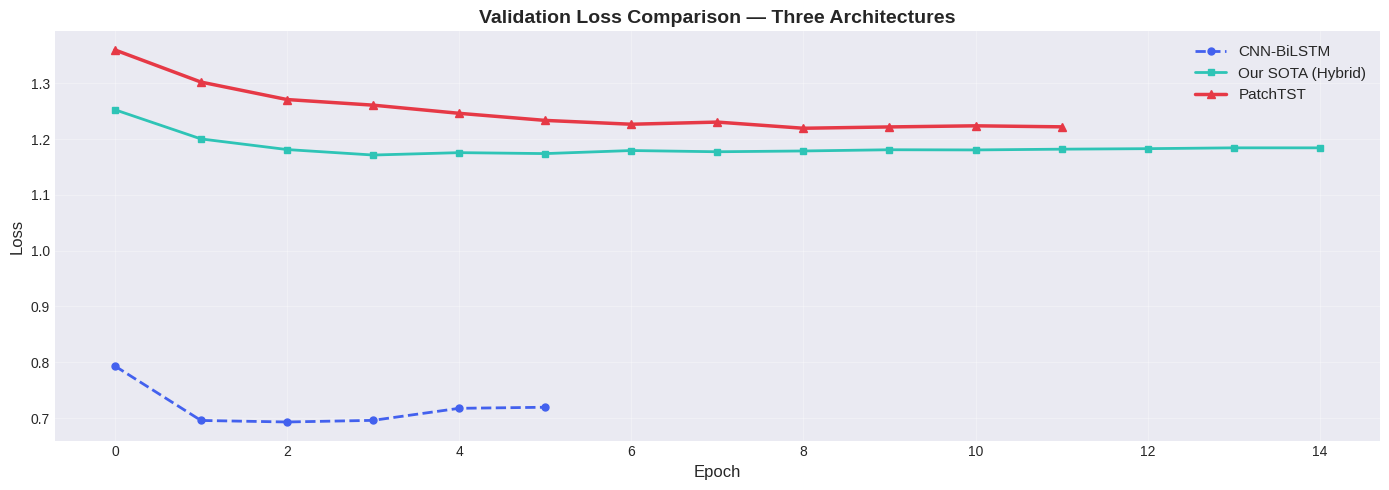

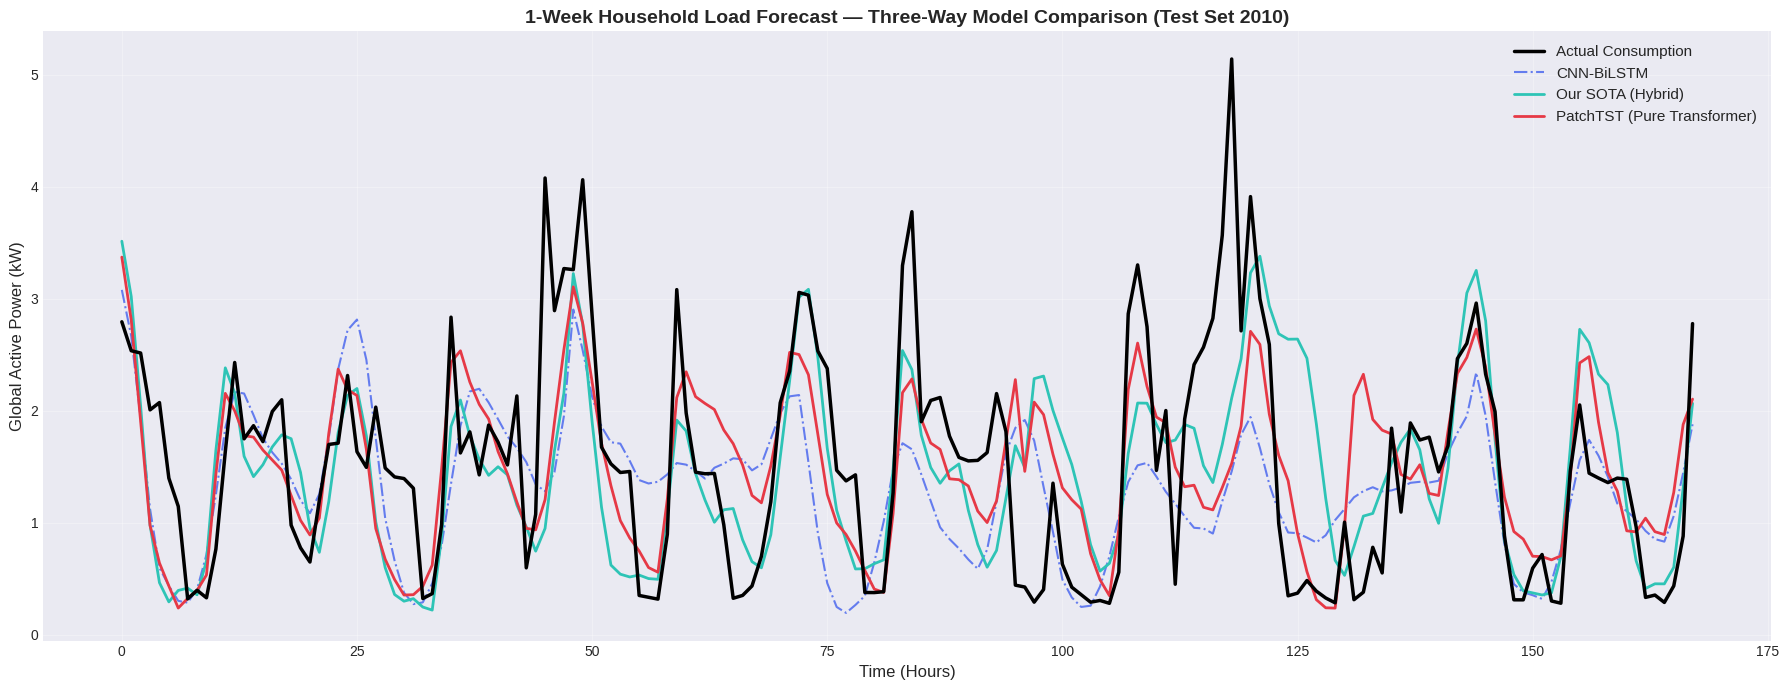

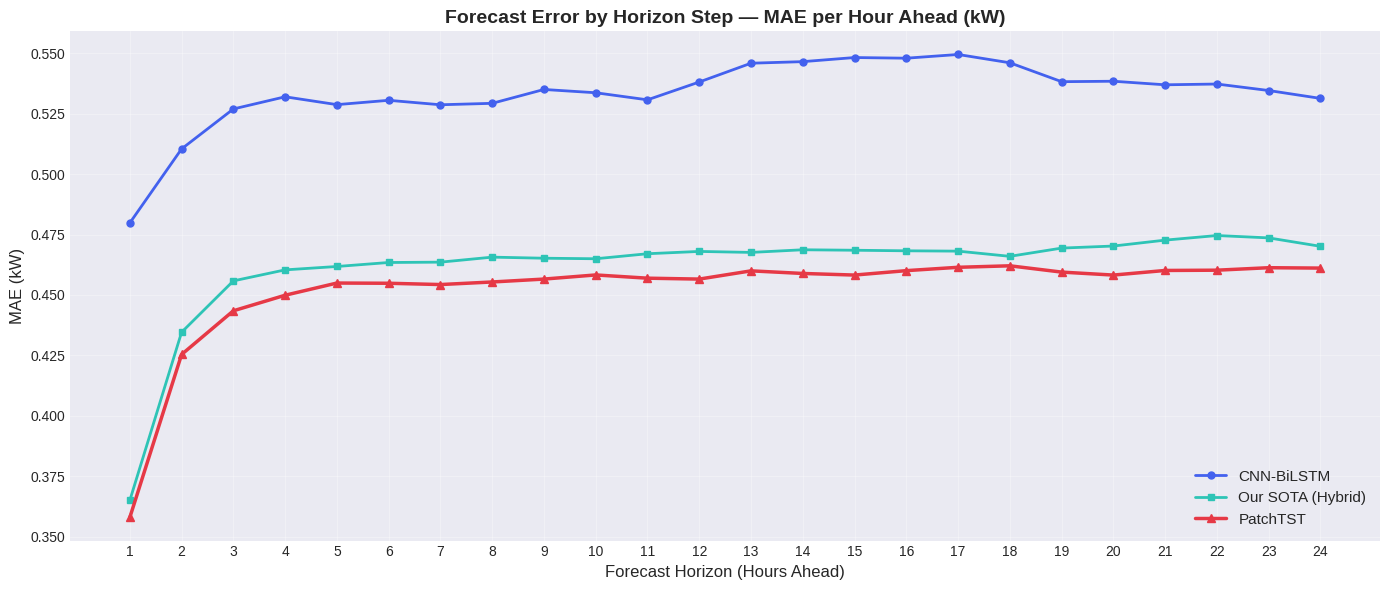


Per-horizon analysis shows how error accumulates with forecast distance.
Models with slower error growth handle long-range dependencies better.


In [15]:
# ======== 10.1 Validation Loss Curves ========
fig, ax = plt.subplots(figsize=(14, 5))

colors = {'CNN-BiLSTM': '#4361EE', 'Our SOTA': '#2EC4B6', 'PatchTST': '#E63946'}

ax.plot(cnn_history['val_loss'], label='CNN-BiLSTM', color=colors['CNN-BiLSTM'], 
        linestyle='--', linewidth=2, marker='o', markersize=5)
ax.plot(sota_history['val_loss'], label='Our SOTA (Hybrid)', color=colors['Our SOTA'], 
        linewidth=2, marker='s', markersize=5)
ax.plot(patchtst_history['val_loss'], label='PatchTST', color=colors['PatchTST'], 
        linewidth=2.5, marker='^', markersize=6)

ax.set_title('Validation Loss Comparison — Three Architectures', fontsize=14, fontweight='bold')
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Loss', fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ======== 10.2 One-Week Forecast Comparison ========
plot_start = 500
plot_len = 168  # 1 week

actuals_plot = []
cnn_plot = []
sota_plot = []
patchtst_plot = []

for i in range(plot_start, plot_start + plot_len, HORIZON):
    if i < len(actuals):
        actuals_plot.extend(actuals[i, :])
        cnn_plot.extend(cnn_preds[i, :])
        sota_plot.extend(sota_preds[i, :])
        patchtst_plot.extend(patchtst_preds[i, :])

fig, ax = plt.subplots(figsize=(18, 7))

ax.plot(actuals_plot, label='Actual Consumption', color='black', linewidth=2.5, zorder=5)
ax.plot(cnn_plot, label='CNN-BiLSTM', color=colors['CNN-BiLSTM'], linestyle='-.', linewidth=1.5, alpha=0.8)
ax.plot(sota_plot, label='Our SOTA (Hybrid)', color=colors['Our SOTA'], linestyle='-', linewidth=2)
ax.plot(patchtst_plot, label='PatchTST (Pure Transformer)', color=colors['PatchTST'], 
        linestyle='-', linewidth=2)

ax.set_title('1-Week Household Load Forecast — Three-Way Model Comparison (Test Set 2010)', 
             fontsize=14, fontweight='bold')
ax.set_xlabel('Time (Hours)', fontsize=12)
ax.set_ylabel('Global Active Power (kW)', fontsize=12)
ax.legend(fontsize=11, loc='upper right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ======== 10.3 Per-Horizon MAE Analysis ========
# Compute MAE at each of the 24 forecast steps
cnn_horizon_mae = np.mean(np.abs(cnn_preds - actuals), axis=0)
sota_horizon_mae = np.mean(np.abs(sota_preds - actuals), axis=0)
patchtst_horizon_mae = np.mean(np.abs(patchtst_preds - actuals), axis=0)

fig, ax = plt.subplots(figsize=(14, 6))

hours = np.arange(1, HORIZON + 1)
ax.plot(hours, cnn_horizon_mae, label='CNN-BiLSTM', color=colors['CNN-BiLSTM'], 
        linewidth=2, marker='o', markersize=5)
ax.plot(hours, sota_horizon_mae, label='Our SOTA (Hybrid)', color=colors['Our SOTA'], 
        linewidth=2, marker='s', markersize=5)
ax.plot(hours, patchtst_horizon_mae, label='PatchTST', color=colors['PatchTST'], 
        linewidth=2.5, marker='^', markersize=6)

ax.set_title('Forecast Error by Horizon Step — MAE per Hour Ahead (kW)', fontsize=14, fontweight='bold')
ax.set_xlabel('Forecast Horizon (Hours Ahead)', fontsize=12)
ax.set_ylabel('MAE (kW)', fontsize=12)
ax.set_xticks(hours)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nPer-horizon analysis shows how error accumulates with forecast distance.")
print("Models with slower error growth handle long-range dependencies better.")


## 11. Save All Model Weights
We save all three models' weights for deployment in the web application.


In [16]:
# 1. Save CNN-BiLSTM
torch.save(cnn_model.state_dict(), 'cnn_bilstm_baseline.pth')
print("✅ Saved CNN-BiLSTM → cnn_bilstm_baseline.pth")

# 2. Save SOTA (extract from SWA wrapper if needed)
if hasattr(sota_model, 'module'):
    sota_state_dict = sota_model.module.state_dict()
else:
    sota_state_dict = sota_model.state_dict()
torch.save(sota_state_dict, 'sota_model_weights.pth')
print("✅ Saved SOTA Hybrid → sota_model_weights.pth")

# 3. Save PatchTST
if hasattr(patchtst_model, 'module'):
    patchtst_state_dict = patchtst_model.module.state_dict()
else:
    patchtst_state_dict = patchtst_model.state_dict()
torch.save(patchtst_state_dict, 'patchtst_weights.pth')
print("✅ Saved PatchTST → patchtst_weights.pth")

print(f"\nFile sizes:")
for f in ['cnn_bilstm_baseline.pth', 'sota_model_weights.pth', 'patchtst_weights.pth']:
    if os.path.exists(f):
        size_mb = os.path.getsize(f) / (1024 * 1024)
        print(f"  {f}: {size_mb:.2f} MB")


✅ Saved CNN-BiLSTM → cnn_bilstm_baseline.pth
✅ Saved SOTA Hybrid → sota_model_weights.pth
✅ Saved PatchTST → patchtst_weights.pth

File sizes:
  cnn_bilstm_baseline.pth: 0.82 MB
  sota_model_weights.pth: 4.86 MB
  patchtst_weights.pth: 1.68 MB


## 12. Summary & Analysis

### Architecture Comparison

| Feature | CNN-BiLSTM | Our SOTA (Hybrid) | PatchTST |
|:---|:---|:---|:---|
| **Architecture Family** | Conv + Recurrent | Hybrid Recurrent-Attention | Pure Transformer |
| **Temporal Backbone** | BiLSTM | BiGRU + Transformer | Self-Attention only |
| **Patching** | None | Multi-scale (P₁=8, P₂=24) | Single-scale (P=16) |
| **Variable Strategy** | Channel-Mixed | CI + Cross-Variable Attn | Strict CI |
| **Normalization** | External StandardScaler | RevIN (internal) | RevIN (internal) |
| **Calendar Features** | Not used | Fused via embedding | Not used |
| **Loss Function** | MSE | Huber + SWA | Huber |
| **Venue** | — | — | ICLR 2023 |

### Key Takeaways
1. **PatchTST vs Our SOTA:** Compares pure attention vs hybrid recurrent-attention for temporal modeling
2. **CI vs Cross-Variable:** Strict channel independence (PatchTST) vs selective cross-variable attention (Our SOTA)
3. **Calendar Features:** Our SOTA explicitly uses temporal context; PatchTST must learn it from data alone
4. **Efficiency:** PatchTST has no recurrent bottleneck — parallelizable and potentially faster on GPU

These three models provide a comprehensive study of **how different architectural paradigms handle residential energy forecasting**.
